# Quantization: Making Large Models Smaller

Models like BERT and LLaMA have millions or even billions of parameters. In this notebook I look at why this is a problem,
what the possible solutions are, and then focus on quantization with some code examples.

## 1. Why are large models a problem?

Each parameter is usually stored as a 32-bit float (4 bytes), so the memory needed just for the weights is:

$$\text{Memory} = \text{number of parameters} \times \text{bytes per parameter}$$

For example, Llama 3.1 8B in FP32 needs $8 \times 10^9 \times 4 = 32$ GB, while a free Colab GPU has about 16 GB, so we can't even load it.
Bigger models are also slower and more expensive to run.

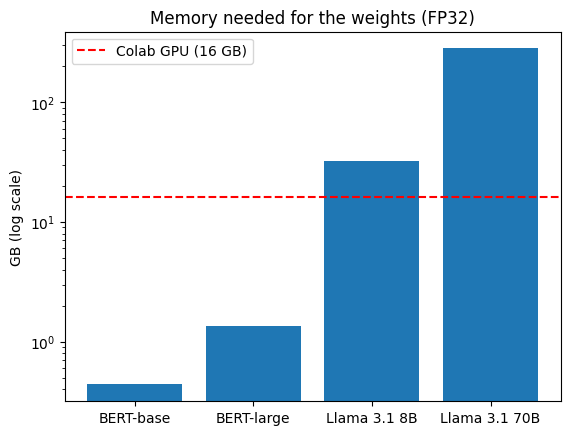

In [18]:
import numpy as np
import matplotlib.pyplot as plt

models = {"BERT-base": 110e6, "BERT-large": 340e6, "Llama 3.1 8B": 8e9, "Llama 3.1 70B": 70e9}
memory = [n * 4 / 1e9 for n in models.values()]   # GB in FP32

plt.bar(models.keys(), memory)
plt.axhline(16, color="red", linestyle="--", label="Colab GPU (16 GB)")
plt.yscale("log")
plt.ylabel("GB (log scale)")
plt.title("Memory needed for the weights (FP32)")
plt.legend()
plt.show()

## 2. How can we solve this?

Some common solutions:

- **Knowledge distillation:** train a small "student" model to imitate a big "teacher" model.
  DistilBERT is an example: it has 66M parameters instead of BERT's 110M (about 40% smaller) and keeps most of its accuracy.
- **Pruning:** remove the weights, neurons or layers that matter least, then usually fine-tune a little to recover accuracy.
- **LoRA (Low-Rank Adaptation):** a cheaper way to *fine-tune* a big model. The original weights $W$ stay frozen
  and only two small matrices $A$ and $B$ are trained:

$$W' = W + BA$$

  For a $768 \times 768$ matrix with rank $r = 8$, LoRA trains $2 \times 768 \times 8 = 12{,}288$ numbers instead of $589{,}824$ (about 2%).
  LoRA makes fine-tuning cheaper, but the model itself keeps its full size.
- **Quantization:** store each weight with fewer bits, for example 8 bits instead of 32.

These methods can be combined. For example, **QLoRA** fine-tunes a 4-bit quantized model with LoRA,
which makes it possible to fine-tune large LLaMA models on a single GPU.

I will focus on quantization because it can be applied directly to an already trained model, usually without retraining.

## 3. Quantization

The idea is to store each weight with fewer bits, for example as an 8-bit integer instead of a 32-bit float.
With $b$ bits we can only represent $2^b$ different values, so fewer bits means less memory but also less precision:

| Type | Bits | Possible values | Bytes per weight | Llama 3.1 8B |
|---|---|---|---|---|
| FP32 | 32 | $\approx 4.3$ billion | 4 | 32 GB |
| FP16 | 16 | 65,536 | 2 | 16 GB |
| INT8 | 8 | 256 | 1 | 8 GB |
| INT4 | 4 | 16 | 0.5 | 4 GB |

The simplest method is absmax (symmetric) quantization. First we compute a scale:

$$s = \frac{\max |w|}{2^{b-1}-1}$$

where $b$ is the number of bits (for 8 bits the denominator is 127). Then we divide by the scale and round:

$$q = \text{round}\left(\frac{w}{s}\right)$$

To use the weights again we multiply back:

$$\hat{w} = q \cdot s$$

$\hat{w}$ is not exactly equal to $w$ because of rounding. This difference is the quantization error.

Rounding moves each value by at most half a step, so the error of every weight is bounded by:

$$|w - \hat{w}| \le \frac{s}{2}$$

This shows what makes the error bigger: a bigger scale $s$, which happens with fewer bits or with a very large $\max |w|$.

## 4. Example 1: a small array

In [19]:
def quantize(w, bits=8):
    q_max = 2 ** (bits - 1) - 1
    scale = np.max(np.abs(w)) / q_max
    q = np.round(w / scale).astype(np.int8)
    return q, scale

def dequantize(q, scale):
    return q * scale

w = np.array([0.12, -0.5, 0.33, 0.9])
q, scale = quantize(w)

print("scale:    ", scale)
print("original: ", w)
print("quantized:", q)
print("restored: ", dequantize(q, scale).round(4))
print("error:    ", (w - dequantize(q, scale)).round(4))

scale:     0.007086614173228346
original:  [ 0.12 -0.5   0.33  0.9 ]
quantized: [ 17 -71  47 127]
restored:  [ 0.1205 -0.5031  0.3331  0.9   ]
error:     [-0.0005  0.0031 -0.0031  0.    ]


The restored values are very close to the original ones, but each value is now stored in 1 byte instead of 4.

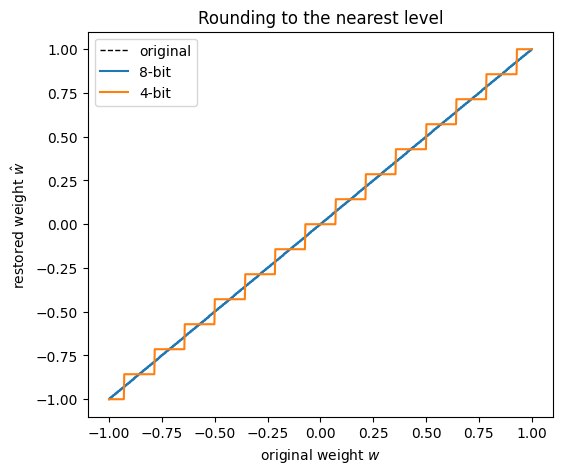

In [20]:
w_line = np.linspace(-1, 1, 1000)

plt.figure(figsize=(6, 5))
plt.plot(w_line, w_line, "k--", linewidth=1, label="original")
for bits in [8, 4]:
    q_line, s_line = quantize(w_line, bits)
    plt.plot(w_line, dequantize(q_line, s_line), label=f"{bits}-bit")
plt.xlabel("original weight $w$")
plt.ylabel(r"restored weight $\hat{w}$")
plt.title("Rounding to the nearest level")
plt.legend()
plt.show()

With 8 bits there are 255 levels, so the steps are too small to see. With 4 bits there are only 15 levels,
so every weight between two levels is rounded to the same value.

## 5. Example 2: a weight matrix (8-bit vs 4-bit)

Here I use a random matrix with the same size as one BERT layer (768 x 768).

In [21]:
np.random.seed(0)
W = np.random.normal(0, 0.02, (768, 768))

for bits in [8, 4]:
    q, s = quantize(W, bits)
    mse = np.mean((W - dequantize(q, s)) ** 2)
    print(f"{bits}-bit  ->  MSE = {mse:.2e}")

8-bit  ->  MSE = 5.17e-08
4-bit  ->  MSE = 1.70e-05


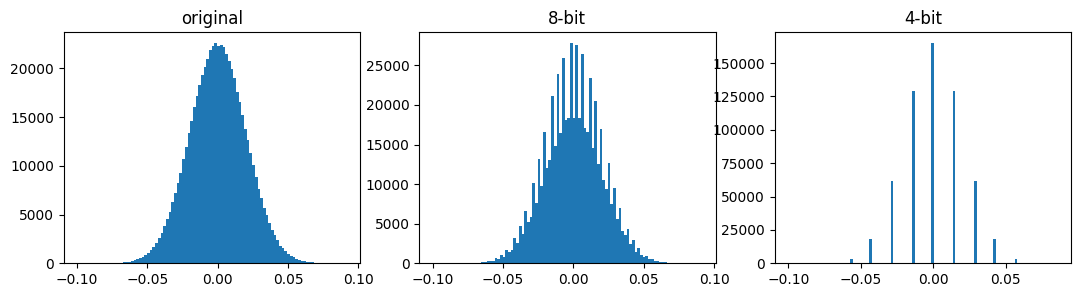

In [22]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3))
ax[0].hist(W.flatten(), bins=100)
ax[0].set_title("original")
for i, bits in enumerate([8, 4]):
    q, s = quantize(W, bits)
    ax[i + 1].hist(dequantize(q, s).flatten(), bins=100)
    ax[i + 1].set_title(f"{bits}-bit")
plt.show()

With 8 bits the distribution stays almost the same. With 4 bits there are only a few possible values, so the error is much larger.

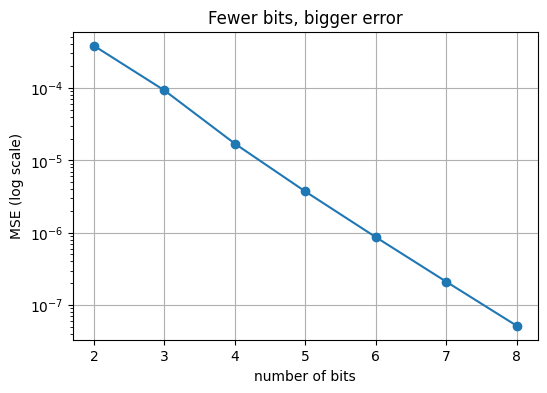

In [23]:
bits_list = [2, 3, 4, 5, 6, 7, 8]
errors = []
for bits in bits_list:
    q, s = quantize(W, bits)
    errors.append(np.mean((W - dequantize(q, s)) ** 2))

plt.figure(figsize=(6, 4))
plt.plot(bits_list, errors, marker="o")
plt.yscale("log")
plt.xlabel("number of bits")
plt.ylabel("MSE (log scale)")
plt.title("Fewer bits, bigger error")
plt.grid(True)
plt.show()

Each bit we remove doubles the step size $s$, so the squared error becomes about 4 times larger.
This is why 8-bit quantization is usually safe, while going below 4 bits loses a lot of information.

### The problem of outliers

Absmax uses the largest weight to set the scale. If one weight is much larger than the others,
the scale becomes large and all the normal weights lose precision.
Here I replace a single weight with 1.0 (the other weights are around ±0.1 at most).

In [24]:
W_outlier = W.copy()
W_outlier[0, 0] = 1.0          # one unusually large weight

for name, M in [("without outlier", W), ("with one outlier", W_outlier)]:
    q, s = quantize(M, 8)
    mse = np.mean((M - dequantize(q, s)) ** 2)
    print(f"{name:17s} ->  scale = {s:.5f},  MSE = {mse:.2e},  weights that became 0: {np.mean(q == 0):.1%}")

without outlier   ->  scale = 0.00079,  MSE = 5.17e-08,  weights that became 0: 1.6%
with one outlier  ->  scale = 0.00787,  MSE = 5.17e-06,  weights that became 0: 15.6%


One weight out of 589,824 made the scale 10 times larger and the error about 100 times larger.
A common fix is to use **one scale per row**, so an outlier only affects its own row:

In [25]:
def quantize_rows(w, bits=8):
    q_max = 2 ** (bits - 1) - 1
    scale = np.max(np.abs(w), axis=1, keepdims=True) / q_max   # one scale per row
    q = np.round(w / scale).astype(np.int8)
    return q, scale

q_rows, s_rows = quantize_rows(W_outlier, 8)
print("one scale per row ->  MSE =", f"{np.mean((W_outlier - dequantize(q_rows, s_rows)) ** 2):.2e}")

one scale per row ->  MSE = 2.96e-08


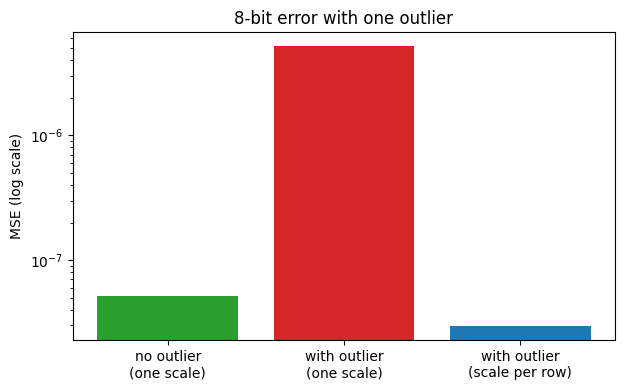

In [26]:
q_one, s_one = quantize(W, 8)
q_out, s_out = quantize(W_outlier, 8)

errors = [
    np.mean((W - dequantize(q_one, s_one)) ** 2),
    np.mean((W_outlier - dequantize(q_out, s_out)) ** 2),
    np.mean((W_outlier - dequantize(q_rows, s_rows)) ** 2),
]
labels = ["no outlier\n(one scale)", "with outlier\n(one scale)", "with outlier\n(scale per row)"]

plt.figure(figsize=(7, 4))
plt.bar(labels, errors, color=["tab:green", "tab:red", "tab:blue"])
plt.yscale("log")
plt.ylabel("MSE (log scale)")
plt.title("8-bit error with one outlier")
plt.show()

With one scale per row, the error is even lower than without the outlier, and the extra cost is small:
768 scales (about 3 KB) for 589,824 weights. Example 3 uses the same idea.

## 6. Example 3: quantizing DistilBERT

Now I apply the same idea to a real model (DistilBERT fine-tuned for sentiment analysis).
I quantize all the weight matrices to 8-bit, using one scale per row (more accurate than one scale for the whole matrix),
and then compare the size and the predictions.

In [27]:
import copy
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)
model.eval()

print("parameters:", sum(p.numel() for p in model.parameters()))

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

parameters: 66955010


FP32: 267.8 MB
INT8: 67.4 MB


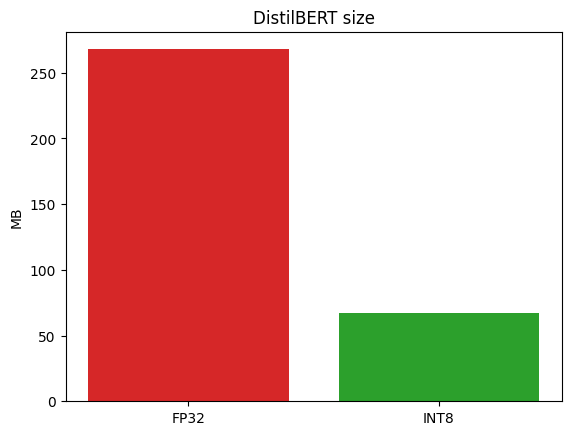

In [28]:
def quantize_tensor(w, bits=8):
    q_max = 2 ** (bits - 1) - 1
    scale = w.abs().max(dim=1, keepdim=True).values / q_max   # one scale per row
    scale = scale.clamp(min=1e-8)
    q = torch.round(w / scale).to(torch.int8)
    return q, scale

model_q = copy.deepcopy(model)
size_fp32, size_int8 = 0, 0

for p in model_q.parameters():
    size_fp32 += p.numel() * 4
    if p.dim() == 2:                  # weight matrices
        q, scale = quantize_tensor(p.data)
        p.data = q.float() * scale    # put the dequantized weights back
        size_int8 += q.numel() + scale.numel() * 4
    else:                             # biases and layer norm stay in FP32
        size_int8 += p.numel() * 4

print(f"FP32: {size_fp32 / 1e6:.1f} MB")
print(f"INT8: {size_int8 / 1e6:.1f} MB")

plt.bar(["FP32", "INT8"], [size_fp32 / 1e6, size_int8 / 1e6], color=["tab:red", "tab:green"])
plt.ylabel("MB")
plt.title("DistilBERT size")
plt.show()

In [29]:
sentences = [
    "This movie was amazing!",
    "I really didn't like the food.",
    "The service was okay, nothing special.",
    "Worst experience ever.",
]

inputs = tokenizer(sentences, padding=True, return_tensors="pt")
with torch.no_grad():
    pos_fp32 = torch.softmax(model(**inputs).logits, dim=1)[:, 1].tolist()
    pos_int8 = torch.softmax(model_q(**inputs).logits, dim=1)[:, 1].tolist()

for s, a, b in zip(sentences, pos_fp32, pos_int8):
    print(f"{s:40s}  P(positive)  FP32: {a:.3f}   INT8: {b:.3f}")

This movie was amazing!                   P(positive)  FP32: 1.000   INT8: 1.000
I really didn't like the food.            P(positive)  FP32: 0.001   INT8: 0.001
The service was okay, nothing special.    P(positive)  FP32: 0.014   INT8: 0.014
Worst experience ever.                    P(positive)  FP32: 0.000   INT8: 0.000


The model is about 4x smaller and the predictions are almost the same.

Note: this example is a simulation. To run the model with normal PyTorch, I put the dequantized weights back
as FP32, so the model in memory is not actually smaller or faster. The sizes above show how much storage
the INT8 weights would need. Libraries like `bitsandbytes` (often used with LLaMA models) really keep
the weights in 8-bit or 4-bit form in GPU memory and convert them back only when computing.

## 7. Pros and cons

**Pros:**

- Much smaller models: 4x smaller with INT8 and 8x smaller with INT4 compared to FP32.
- They can run on cheaper hardware: Llama 3.1 8B needs 32 GB in FP32 but about 8 GB in INT8 or 4 GB in INT4, so it fits on a free Colab GPU.
- Usually no retraining is needed: quantization can be applied to an already trained model.

**Cons:**

- Some accuracy is lost. It is very small with 8 bits but grows quickly with fewer bits (about 4x more error for every bit removed in Example 2).
- Outliers make the scale large, so practical methods use one scale per row or per small block of weights.
- The speed-up depends on hardware and library support. Example 3 is a simulation, so it shows the size and the accuracy but is not faster.

## Conclusion

Large models like BERT and LLaMA need a lot of memory because every parameter takes 4 bytes in FP32.
Quantization reduces this by storing the weights with fewer bits.
In the examples, 8-bit absmax quantization kept the weights very close to the original, while 4-bit gave about 330 times more error on the test matrix.
A single outlier made the 8-bit error about 100 times larger, and using one scale per row fixed this.
Finally, 8-bit quantization made DistilBERT about 4 times smaller while giving almost the same predictions.